# Benchmarking Forcefields and Solvation Models for Cyclic Peptides
This notebook evaluates the performance of a curated spread of contemporary OpenMM forcefields and implicit solvent models. Performance is measured by the ability of the `CyclicPeptideOptimiser` to find low-energy states that closely reproduce the known experimental PDB structures.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser, Superimposer
from Bio.PDB.PDBList import PDBList
from IPython.display import display
from isambard.optimisation.cyclic_peptide_optimiser import CyclicPeptideOptimiser
from openmm.app import PDBFile

%matplotlib inline

In [2]:
# Targets identified from the original notebook
macs = {
    7.1: 'TkNDTnp',
    7.2: 'hPdqseP',
    7.3: 'QDPpKtd',
    8.1: 'DDPTprQq',
    8.2: 'rQpqRePQ',
    9.1: 'pPYhPKDLq',
    10.1: 'PEAARvpRlt',
    10.2: 'EvDPehpNap'
}

pdbs = {
    7.1: '6be9',
    7.2: '6bew',
    7.3: '6bf5',
    8.1: '6be7',
    8.2: '6ben',
    9.1: '6beo',
    10.1: '6beq',
    10.2: '6ber'
}

In [3]:
# Helper function to calculate C-alpha RMSD to native structure
def calculate_ca_rmsd(ref_pdb_file, mob_pdb_file):
    parser = PDBParser(QUIET=True)
    
    def get_ca_atoms(structure):
        ca_atoms = []
        # Use the first model (index 0) for NMR ensembles
        model = structure[0]
        for chain in model:
            for residue in chain:
                if 'CA' in residue:
                    ca_atoms.append(residue['CA'])
        return ca_atoms

    try:
        ref_struct = parser.get_structure('ref', ref_pdb_file)
        mob_struct = parser.get_structure('mob', mob_pdb_file)
        
        ref_ca = get_ca_atoms(ref_struct)
        mob_ca = get_ca_atoms(mob_struct)
        
        if len(ref_ca) != len(mob_ca):
            print(f"Warning: Length mismatch ({len(ref_ca)} vs {len(mob_ca)}). Cannot compute RMSD.")
            return np.nan
            
        sup = Superimposer()
        sup.set_atoms(ref_ca, mob_ca)
        return sup.rms
    except Exception as e:
        print(f"Error computing RMSD: {e}")
        return np.nan

pdbl = PDBList()


Testing target 6be9 (Sequence: TkNDTnp)
Structure exists: './pdb6be9.ent' 

--- Configuration: amber14-all_obc2 ---
Starting rmsd is 1.316475906181045
At iter 19500 best rmsd is 0.05135337616010909)
After 19502 iterations and 0 attempts best rmsd is 0.049674843684018526
optimising sequence TkNDTnp
 HOF at iter 199 is [-1189.472109258175, -1181.1959729790688, -1181.1104418039322, -1176.4125800132751, -1167.9532806873322, -1167.3073507845402, -1166.6927061080933, -1165.5933406054974, -1164.6144862174988, -1160.0837712287903] best -1189.472109258175 worst -596.9004029631615 rama 86.80000000000003                                                                                                      Finished in 310.53s | Energy: -1189.47 | CA-RMSD: 1.28 Å

--- Configuration: amber14-all_gbn2 ---
Starting rmsd is 1.052422646809675
At iter 19900 best rmsd is 0.6536795411813727)
Managed only rmsd of 0.6549585748525484: resampling!
At iter 8600 best rmsd is 0.05897613040174482)
After 8659 iterat

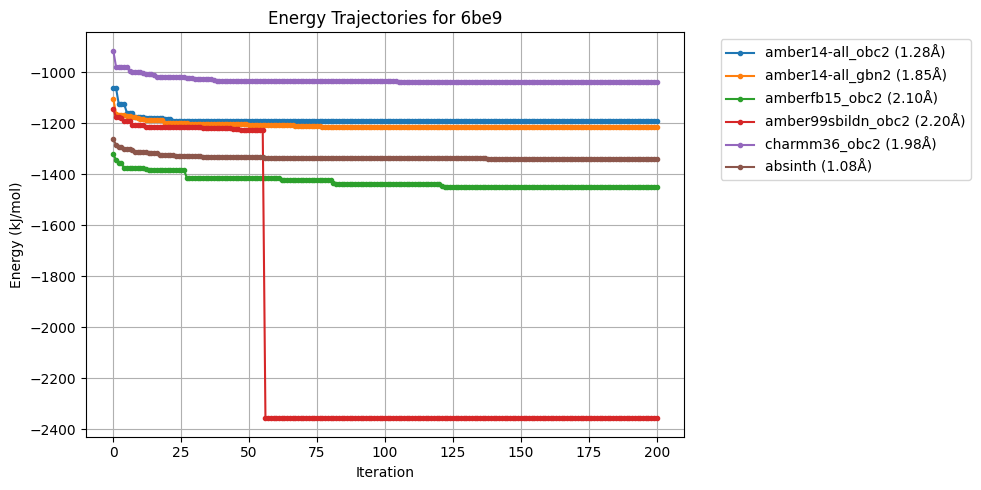


Testing target 6bew (Sequence: hPdqseP)

--- Configuration: amber14-all_obc2 ---
Starting rmsd is 1.4368561414432752
At iter 9600 best rmsd is 0.05213540838776406)
After 9655 iterations and 0 attempts best rmsd is 0.04843736695803746
optimising sequence hPdqseP
 HOF at iter 199 is [-651.9573245048523, -647.9313974380493, -647.7539883255959, -639.9883434772491, -638.7314059734344, -638.6603376865387, -636.9042429924011, -634.2579855918884, -624.1843982934952, -622.0739699602127] best -651.9573245048523 worst -406.95841908454895 rama 82.46666666666667                                                                                                    Finished in 294.02s | Energy: -651.96 | CA-RMSD: 1.23 Å

--- Configuration: amber14-all_gbn2 ---
Starting rmsd is 1.6889560004962587
At iter 10600 best rmsd is 0.05315514962256172)
After 10640 iterations and 0 attempts best rmsd is 0.04982476145795352
optimising sequence hPdqseP
 HOF at iter 199 is [-690.7002409100533, -686.4753506183624, -68

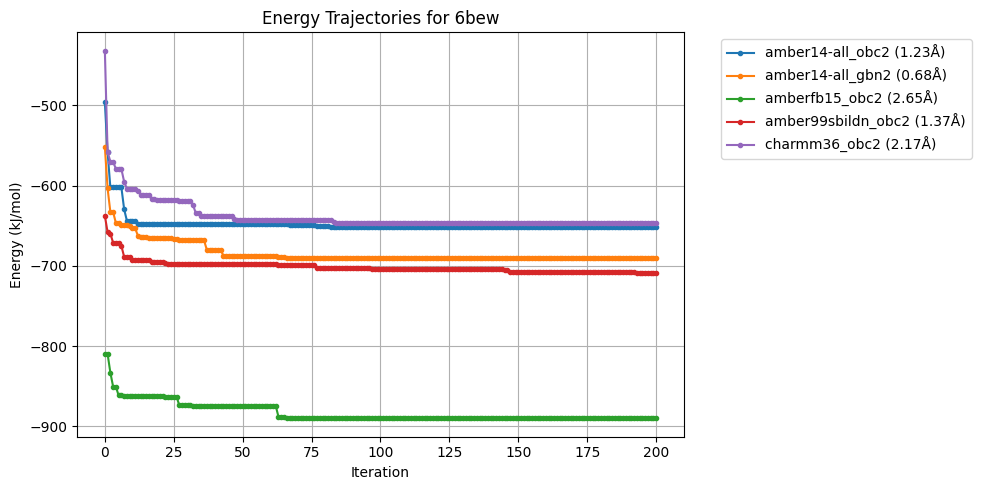


Testing target 6bf5 (Sequence: QDPpKtd)

--- Configuration: amber14-all_obc2 ---
Starting rmsd is 1.6510074674777198
At iter 19200 best rmsd is 0.05363374720638567)
After 19220 iterations and 0 attempts best rmsd is 0.048724136134849834
optimising sequence QDPpKtd
 HOF at iter 199 is [-885.7450076341629, -881.3913688659668, -880.1607327461243, -878.6897920370102, -876.9883665442467, -869.520369887352, -867.3433149755001, -865.2015939950943, -864.1954281330109, -861.6287467479706] best -885.7450076341629 worst -194.63173294067383 rama 76.20000000000003                                                                                                     Finished in 311.24s | Energy: -885.75 | CA-RMSD: 1.08 Å

--- Configuration: amber14-all_gbn2 ---
Starting rmsd is 1.9569260370544839
At iter 19900 best rmsd is 0.12791339347715108)
Managed only rmsd of 0.12570457609593236: resampling!
At iter 9600 best rmsd is 0.05490579923263107)
After 9649 iterations and 1 attempts best rmsd is 0.0489630

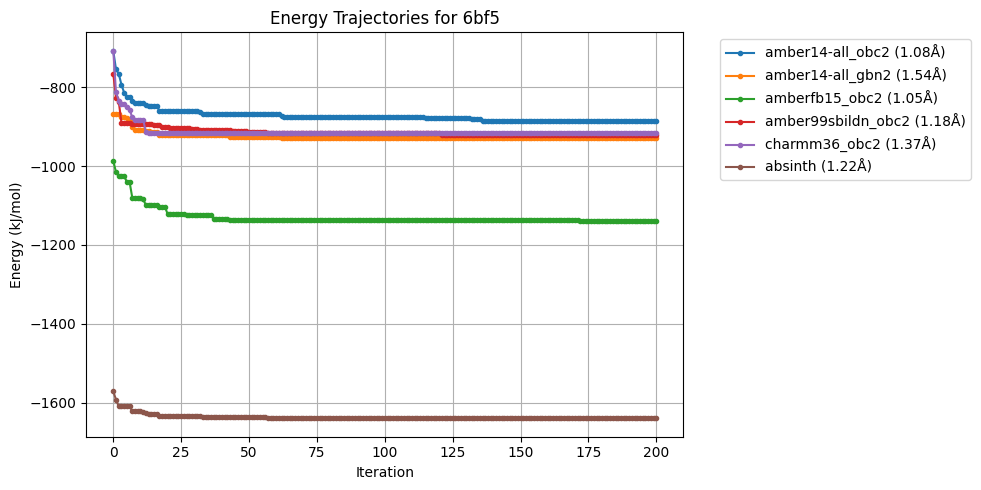


Testing target 6be7 (Sequence: DDPTprQq)

--- Configuration: amber14-all_obc2 ---
Starting rmsd is 1.992307461682354
At iter 7200 best rmsd is 0.06427602601476538)
After 7269 iterations and 0 attempts best rmsd is 0.04890783992180411
optimising sequence DDPTprQq
 HOF at iter 199 is [-1849.163314819336, -1843.9005494117737, -1839.1258487701416, -1837.9391345977783, -1831.5968570709229, -1831.5581912994385, -1826.063066482544, -1822.5182266235352, -1820.721676826477, -1817.3906245231628] best -1849.163314819336 worst -1048.1071872711182 rama 77.4666666666667                                                                                                         Finished in 307.18s | Energy: -1849.16 | CA-RMSD: 0.61 Å

--- Configuration: amber14-all_gbn2 ---
Starting rmsd is 1.5915667926634973
At iter 15900 best rmsd is 0.05816492750571572)
After 15950 iterations and 0 attempts best rmsd is 0.04914457575959723
optimising sequence DDPTprQq
 HOF at iter 199 is [-1932.7008485794067, -1916.61

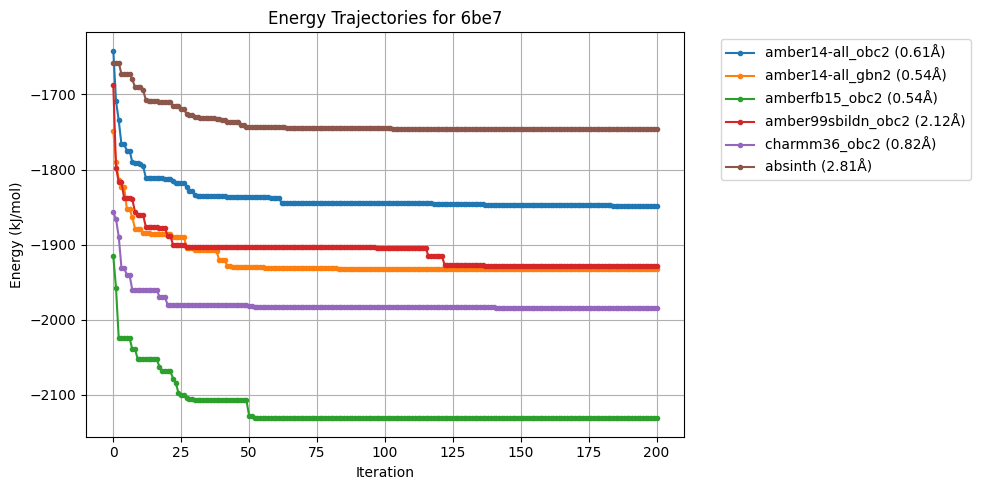

In [4]:
# Curated spread of contemporary forcefields and implicit solvent models
configurations = [
    ('amber14-all.xml', 'implicit/obc2.xml'),   # Standard Baseline
    ('amber14-all.xml', 'implicit/gbn2.xml'),   # Structural Baseline (GB-Neck2)
    ('amberfb15.xml', 'implicit/obc2.xml'),     # Modern AMBER (ForceBalance)
    ('amber99sbildn.xml', 'implicit/obc2.xml'), # Classic Rotamer-optimized
    ('charmm36.xml', 'implicit/obc2.xml'),      # CHARMM Competitor
    ('amoeba2018_gk.xml', None),                # Polarizable Heavyweight
    ('absinth.xml', None)                       # Specialized Solvation Paradigm
]

# Test targets (selecting a mix to keep runtimes reasonable)
test_keys = [7.1, 7.2, 7.3, 8.1]

# Data collection
results_data = []

for k in test_keys:
    seq = macs[k]
    pdb_id = pdbs[k]
    print(f"\n{'='*60}\nTesting target {pdb_id} (Sequence: {seq})\n{'='*60}")
    
    # Fetch native PDB for RMSD comparison
    native_pdb = pdbl.retrieve_pdb_file(pdb_id, pdir='.', file_format='pdb')
    
    plt.figure(figsize=(10, 5))
    plt.title(f'Energy Trajectories for {pdb_id}')
    plt.xlabel('Iteration')
    plt.ylabel('Energy (kJ/mol)')
    
    for ff, solv in configurations:
        if solv is not None:
            label = f"{ff.split('.')[0]}_{solv.split('/')[-1].split('.')[0]}"
        else:
            label = f"{ff.split('.')[0]}"
            
        print(f"\n--- Configuration: {label} ---")
        
        try:
            t1 = time.time()
            
            opt = CyclicPeptideOptimiser(seq, forcefield=ff, implicit_solvent=solv)
            opt.build_start_mac()
            opt.amber_setup()
            
            # Run optimization (100 iterations for benchmarking speed/effectiveness)
            opt.optimise(
                n_iter=200,
                samplesize=20,
                wp_len=20, 
                hof_len=10, 
                rama_rmsd=5, 
                n_permute=10, 
                plot=False
            )
            
            t2 = time.time()
            best_energy = opt.energies[-1]
            
            # Save the best structure
            output_pdb = f'{pdb_id}_{label}_best.pdb'
            with open(output_pdb, 'w') as f:
                PDBFile.writeFile(opt.model.topology, opt.halloffame[0][1], file=f)
                
            # Calculate C-alpha RMSD to native structure
            rmsd = calculate_ca_rmsd(native_pdb, output_pdb)
            
            print(f"Finished in {t2 - t1:.2f}s | Energy: {best_energy:.2f} | CA-RMSD: {rmsd:.2f} Å")
            
            # Store results
            results_data.append({
                'Target': pdb_id,
                'Sequence': seq,
                'Configuration': label,
                'RMSD (Å)': rmsd,
                'Energy': best_energy,
                'Time (s)': t2 - t1
            })
            
            # Plot trajectory
            plt.plot(range(len(opt.energies)), opt.energies, marker='o', markersize=3, label=f"{label} ({rmsd:.2f}Å)")
            
        except Exception as e:
            print(f"Configuration {label} failed: {e}")
            
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [5]:
# Summarize Results in a Pandas DataFrame
df = pd.DataFrame(results_data)

# Create a pivot table to easily compare RMSD across configurations and targets
rmsd_matrix = df.pivot(index='Target', columns='Configuration', values='RMSD (Å)')

print("\n=== CA-RMSD (Å) Summary Matrix ===")
display(rmsd_matrix.round(2))

print("\n=== Average RMSD by Configuration ===")
display(rmsd_matrix.mean().sort_values().to_frame(name='Avg RMSD (Å)').round(2))


=== CA-RMSD (Å) Summary Matrix ===


Configuration,absinth,amber14-all_gbn2,amber14-all_obc2,amber99sbildn_obc2,amberfb15_obc2,charmm36_obc2
Target,,,,,,
6be7,2.81,0.54,0.61,2.12,0.54,0.82
6be9,1.08,1.85,1.28,2.20,2.10,1.98
6bew,NaN,0.68,1.23,1.37,2.65,2.17
6bf5,1.22,1.54,1.08,1.18,1.05,1.37



=== Average RMSD by Configuration ===


,Avg RMSD (Å)
Configuration,
amber14-all_obc2,1.05
amber14-all_gbn2,1.15
amberfb15_obc2,1.58
charmm36_obc2,1.59
absinth,1.71
amber99sbildn_obc2,1.72
